In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

from graphufs.stacked_utils import convert_loss_channel2var, get_channel_index
from graphufs.datasets import Dataset

In [2]:
# local variables
_scratch = "/pscratch/sd/n/nagarwal/"
_prototype = "ocn-only"
_expt = "R4"

In [5]:
# stacked normalization
moment = "stddev"
file_name = f"{moment}_by_level.zarr"
stacked_norm = os.path.join(_scratch, _prototype, _expt, "std_inputs", file_name)

In [6]:
# open the moment file
moment = xr.open_zarr(stacked_norm)
moment

<xarray.Dataset> Size: 35MB
Dimensions:  (lat: 192, lon: 384, channels: 59)
Coordinates:
  * lat      (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Dimensions without coordinates: channels
Data variables:
    inputs   (lat, lon, channels) float64 35MB dask.array<chunksize=(48, 96, 30), meta=np.ndarray>

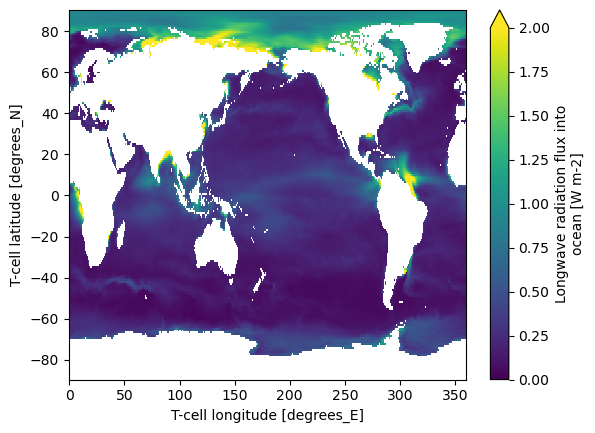

In [12]:
moment.inputs.isel(channels=13).plot(vmin=0, vmax=2)
plt.show()

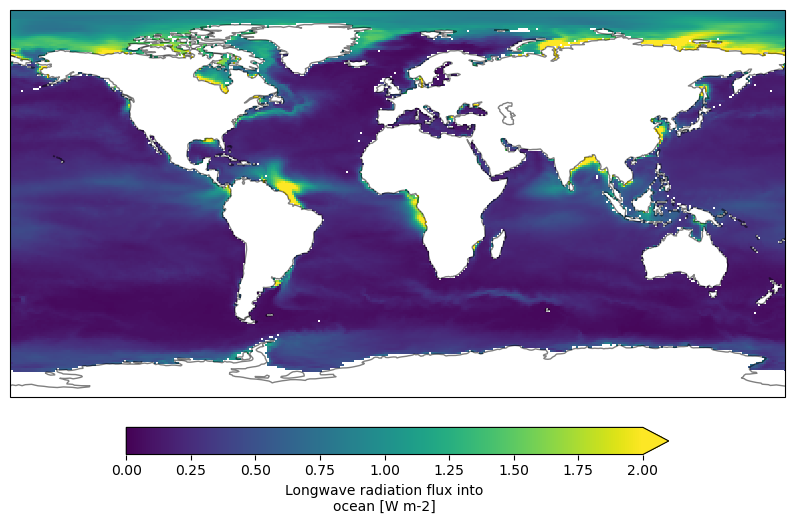

In [23]:
import cartopy.crs as ccrs
channel = 13
field = xr.DataArray(moment.inputs.isel(channels=channel),
                     dims = ["lat", "lon"],
                     coords = {"lat": moment.coords["lat"].values,
                               "lon": moment.coords["lon"].values})

fig, ax = plt.subplots(1, 1, figsize=(10,8), subplot_kw=dict(projection=ccrs.PlateCarree()))
kwargs = {"cbar_kwargs":{"orientation": "horizontal", "shrink":0.7, "pad":0.05}, 
          "robust":True, "cmap":"viridis", "vmin":0, "vmax":2,}
field.plot(ax=ax, **kwargs)
ax.coastlines(alpha=0.5)
plt.savefig("figures/std_SSS.png", dpi=300)
plt.show()

# Verification

In [20]:
# For verification, open the corresponding named variable statistics
norm = os.path.join(_scratch, _prototype, _expt, "normalization", file_name)
moment_verify = xr.open_zarr(norm)
moment_verify

<xarray.Dataset> Size: 24MB
Dimensions:            (lat: 192, lon: 384, grid_xt: 384, grid_yt: 192, z_l: 7,
                        level: 1)
Coordinates:
  * grid_xt            (grid_xt) float64 3kB 0.0 0.9375 1.875 ... 358.1 359.1
  * grid_yt            (grid_yt) float64 2kB 89.82 88.89 87.95 ... -88.18 -89.12
  * lat                (lat) float64 2kB 89.82 88.89 87.95 ... -88.18 -89.12
  * level              (level) float64 8B 974.3
  * lon                (lon) float64 3kB 0.0 0.9375 1.875 ... 357.2 358.1 359.1
  * z_l                (z_l) float64 56B 0.5154 11.06 47.21 ... 271.2 417.7
Data variables: (12/18)
    LW                 (lat, lon) float32 295kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    SSH                (lat, lon) float32 295kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    SW                 (lat, lon) float32 295kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    day_progress_cos   (grid_xt) float32 2kB dask.array<chunksize=(384,), meta=np.ndarray>
    day_progress_sin   (grid_xt) float32 2kB dask.array<chunksize=(384,), meta=np.ndarray>
    land_static        (grid_yt, grid_xt) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    ...                 ...
    ugrd10m            (grid_yt, grid_xt) float32 295kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    uo                 (z_l, lat, lon) float64 4MB dask.array<chunksize=(7, 192, 384), meta=np.ndarray>
    vgrd10m            (grid_yt, grid_xt) float32 295kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    vo                 (z_l, lat, lon) float64 4MB dask.array<chunksize=(7, 192, 384), meta=np.ndarray>
    year_progress_cos  float64 8B ...
    year_progress_sin  float64 8B ...

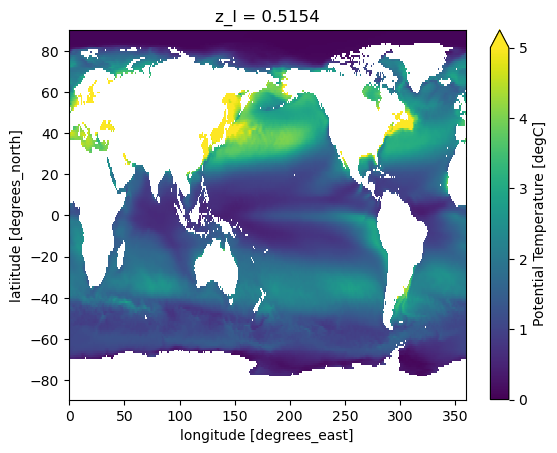

In [27]:
moment_verify.temp.isel(z_l=0).plot(vmin=0, vmax=5,)
plt.show()